### Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Import Gmbar

In [2]:
img = cv2.imread('Assets/Nama1.jpeg')
if img is None:
    print("Citra tidak dapat dimuat. Pastikan path gambar benar.")
else:
    print("Citra berhasil dimuat.")

Citra berhasil dimuat.


### Mencari Ambang Batas

In [3]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


# ==== Deteksi Warna ====
# === Merah
mask_red = cv2.bitwise_or(
    cv2.inRange(hsv, np.array([0, 70, 50]), np.array([10, 255, 255])),
    cv2.inRange(hsv, np.array([170, 70, 50]), np.array([180, 255, 255]))
)
# === Hijau
mask_green = cv2.inRange(hsv, np.array([36, 50, 50]), np.array([89, 255, 255]))
# === Biru
mask_blue = cv2.inRange(hsv, np.array([90, 50, 50]), np.array([130, 255, 255]))

In [4]:
combined_none = np.zeros_like(mask_red)
combined_blue = mask_blue
combined_red_blue = cv2.bitwise_or(mask_red, mask_blue)
combined_rgb = cv2.bitwise_or(cv2.bitwise_or(mask_red, mask_blue), mask_green)

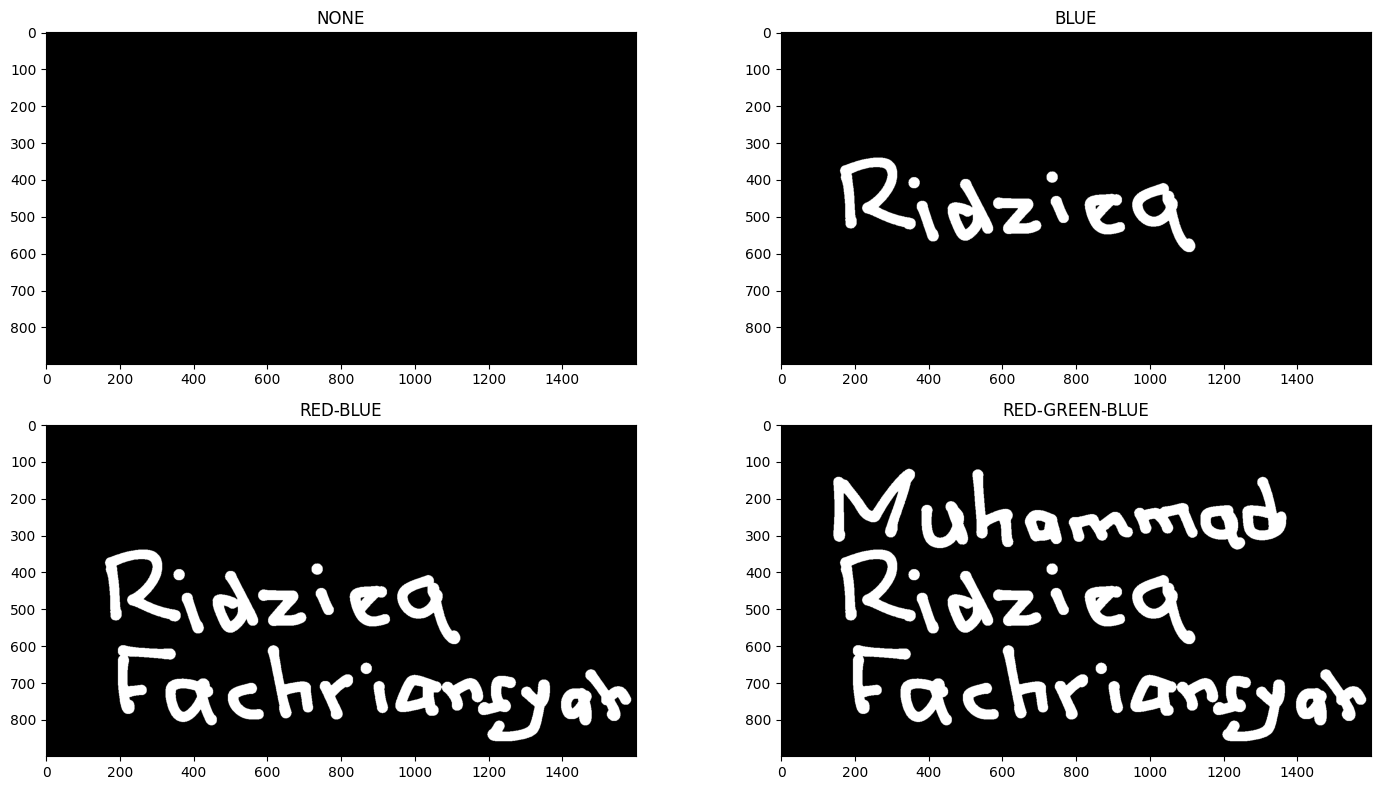

Ambang batas warna:
Merah: [0-10] & [160-180] H
Hijau: [36-89] H
Biru : [90-130] H


In [9]:
# Gambar kombinasi
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(combined_none, cmap='gray')
plt.title('NONE')

plt.subplot(2, 2, 2)
plt.imshow(combined_blue, cmap='gray')
plt.title('BLUE')

plt.subplot(2, 2, 3)
plt.imshow(combined_red_blue, cmap='gray')
plt.title('RED-BLUE')

plt.subplot(2, 2, 4)
plt.imshow(combined_rgb, cmap='gray')
plt.title('RED-GREEN-BLUE')

plt.tight_layout()
plt.show()

print("Ambang batas warna:")
print("Merah: [0-10] & [160-180] H")
print("Hijau: [36-89] H")
print("Biru : [90-130] H")

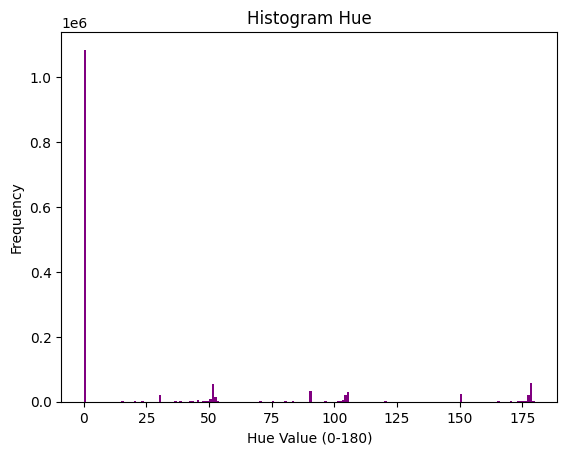

In [8]:
# Ekstrak channel Hue
hue_channel = hsv[:, :, 0]

# Plot histogram Hue
plt.hist(hue_channel.ravel(), bins=180, range=[0, 180], color='purple')
plt.title('Histogram Hue')
plt.xlabel('Hue Value (0-180)')
plt.ylabel('Frequency')
plt.show()